[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_2_4_2_MLR_Ames_Part2_Revised.ipynb)

# MLR Predicting Housing Prices in Ames Iowa: Part 2
## Forward and Backward Selection with Cross-Validation

**In this notebook we will:**
1.  Encode categorical features for linear regression.
2.  Build a baseline model using forward feature selection and cross-validation.
3.  Diagnose problems with the model: negative coefficients, heteroscedastic residuals, and multicollinearity.
4.  Fix them with a log transform of the target variable.
5.  Test polynomial features to capture non-linear relationships.
6.  Assess multicollinearity with VIF and correlation analysis.

**Data Source:** http://jse.amstat.org/v19n3/decock/AmesHousing.txt

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download the cleaning module from GitHub
import urllib.request
module_url = "https://raw.githubusercontent.com/bsheese/cs377/main/17_regression_crossval/ames_cleaning.py"
urllib.request.urlretrieve(module_url, "ames_cleaning.py")
from ames_cleaning import load_and_clean_ames

# Load and clean the Ames dataset
df = load_and_clean_ames(one_hot_encode=False)
print(f"DataFrame shape: {df.shape}")


DataFrame shape: (2925, 38)


## One-Hot Encoding

Machine learning models require numeric input. We use `pd.get_dummies` to turn our text categories into columns of 1s and 0s.

**Why `drop_first=True`?** Without it, you create the "Dummy Variable Trap" — perfect multicollinearity. If you have a feature with 3 categories (A, B, C) and create 3 binary columns, then knowing A=0 and B=0 tells you C must be 1. The third column is perfectly predictable from the others, which breaks the math behind linear regression. Dropping one category removes this redundancy.

In [2]:
# Identify multi-level categories
df = pd.get_dummies(df, columns=df.select_dtypes(include='category').columns, drop_first=True)
df.info()

<class 'pandas.DataFrame'>
Index: 2925 entries, 0 to 2929
Data columns (total 38 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   MS SubClass            2925 non-null   int64  
 1   Lot Frontage           2925 non-null   float64
 2   Lot Area               2925 non-null   int64  
 3   Overall Qual           2925 non-null   int64  
 4   Overall Cond           2925 non-null   int64  
 5   Year Built             2925 non-null   int64  
 6   Year Remod/Add         2925 non-null   int64  
 7   Foundation             2925 non-null   int8   
 8   BsmtFin SF 1           2925 non-null   float64
 9   BsmtFin SF 2           2925 non-null   boolean
 10  Bsmt Unf SF            2925 non-null   float64
 11  Total Bsmt SF          2925 non-null   float64
 12  1st Flr SF             2925 non-null   int64  
 13  2nd Flr SF             2925 non-null   int64  
 14  Gr Liv Area            2925 non-null   int64  
 15  Bsmt Full Bath      

## How Forward and Backward Selection Work

Instead of guessing which features matter, we let the data tell us. These algorithms search through possible feature combinations using cross-validation to evaluate each one.

### Forward Selection (Start Empty, Add Features)

1.  **Start with no features.** The model predicts the average price for every house.
2.  **Try adding each remaining feature, one at a time.** For each candidate, train the model with cross-validation and record the score.
3.  **Pick the feature that improves the score the most.** Add it to the model permanently.
4.  **Repeat.** Try adding each remaining feature to the growing set. Pick the best.
5.  **Stop when no feature improves the score.**

**Mini-example:** Imagine 3 features: A, B, C.
- Step 1: Try A alone (R²=0.50), B alone (R²=0.60), C alone (R²=0.40). Pick **B**.
- Step 2: Try B+A (R²=0.70), B+C (R²=0.65). Pick **A**.
- Step 3: Try B+A+C (R²=0.68). Adding C made things *worse*. Stop.
- Final model: **{A, B}**.

The `n_features_to_select='auto'` parameter means the algorithm keeps adding features as long as each new one improves the cross-validation score. When adding the next feature makes things worse, it stops.

### Backward Selection (Start Full, Remove Features)

The reverse approach:
1.  **Start with all features.**
2.  **Try removing each feature, one at a time.** See which removal hurts the score the *least*.
3.  **Remove the least important feature.**
4.  **Repeat** until removing any feature would significantly hurt performance.

Forward selection is faster when you have many features. Backward selection can catch interactions that forward selection misses, but it's computationally heavier.

### The Selection and Evaluation Function

Below is a function that wraps the entire process: it builds a pipeline (scaler + feature selector + model), runs cross-validation, and returns the results. The pipeline ensures that scaling and feature selection happen *inside* each CV fold, preventing data leakage.

**Note on Cross-Validation Folds:** We use only 2 CV folds to keep computation time manageable for this exercise. In production, use 5-10 folds for more reliable estimates. Using fewer folds is a common trade-off when iterating quickly during model development.

In [3]:
from typing import Dict, Any
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split


def perform_feature_selection_and_evaluation(
    X: pd.DataFrame,
    y: pd.Series,
    selection_direction: str = 'forward',
    cv_folds: int = 2
) -> Dict[str, Any]:
    """
    Performs feature selection and evaluates a Linear Regression model using cross-validation.
    Uses a Pipeline to prevent data leakage during cross-validation.

    Args:
        X (pd.DataFrame): Independent variables.
        y (pd.Series): Dependent variable.
        selection_direction (str): 'forward' or 'backward' for SequentialFeatureSelector.
        cv_folds (int): Number of cross-validation folds.

    Returns:
        dict: A dictionary containing the fitted pipeline, selected feature names, and CV metrics.
    """

    # 1. Build a Pipeline to prevent Data Leakage
    # Everything inside the pipeline is strictly applied to the training folds during CV.
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('selector', SequentialFeatureSelector(
            LinearRegression(),
            n_features_to_select='auto',
            direction=selection_direction,
            cv=cv_folds
        )),
        ('model', LinearRegression())
    ])

    # 2. Perform Cross-Validation efficiently in one pass
    # Using built-in string aliases for standard metrics
    scoring_metrics = ['r2', 'neg_mean_squared_error']
    cv_results = cross_validate(pipeline, X, y, cv=cv_folds, scoring=scoring_metrics)

    # Extract metrics (negating MSE to make it positive)
    # It's initially negative becuase scikit-learn follows a "Higher is Better" convention for all its scoring metrics.
    cv_r2 = cv_results['test_r2']
    cv_mse = -cv_results['test_neg_mean_squared_error']

    print(f"Cross-validated R-squared (mean \u00b1 std): {cv_r2.mean():.4f} \u00b1 {cv_r2.std():.4f}")
    print(f"Cross-validated Mean Squared Error (mean \u00b1 std): {cv_mse.mean():.4f} \u00b1 {cv_mse.std():.4f}\n")

    # 3. Fit the pipeline on the ENTIRE dataset passed to this function
    # (typically either the training or the test set, not the complete dataset, see below)
    # to get final features and coefficients
    pipeline.fit(X, y)

    # Extract the fitted steps from the pipeline
    final_selector = pipeline.named_steps['selector']
    final_model = pipeline.named_steps['model']

    # Identify selected features
    selected_mask = final_selector.get_support()
    selected_feature_names = X.columns[selected_mask].tolist()

    # 4. Print results
    print(f"Intercept: {final_model.intercept_:.4f}\n")
    print(f"Standardized Coefficients (Betas) from full data fit (using {selection_direction} selection):")

    if selected_feature_names:
        max_feature_len = max(len(feature) for feature in selected_feature_names)
        for name, coef in zip(selected_feature_names, final_model.coef_):
            print(f"\t{name.ljust(max_feature_len)}:\t {coef:>7.2f}")
    else:
        print("\tNo features selected.")

    # 5. Return a useful dictionary instead of `None`
    return {
        'model_pipeline': pipeline,
        'selected_features': selected_feature_names,
        'cv_r2_mean': cv_r2.mean(),
        'cv_r2_std': cv_r2.std(),
        'cv_mse_mean': cv_mse.mean(),
        'cv_mse_std': cv_mse.std()
    }

### The Modeling Workflow

This function encapsulates the full pipeline: train-test split, cross-validation with feature selection, test set evaluation, and residual plotting. We'll call it for both forward and backward selection to compare.

In [4]:
def run_modeling_workflow(
    X: pd.DataFrame,
    y: pd.Series,
    test_size: float = 0.20,
    random_state: int = 42,
    selection_direction: str = 'forward',
    cv_folds: int = 2,
    plot_residuals: bool = True
) -> Dict[str, Any]:
  """
  Encapsulates the entire MLR modeling workflow including train-test split,
  feature selection, model training, evaluation, and optional residual plotting.

  Args:
    X (pd.DataFrame): Independent variables (or Features).
    y (pd.Series): Dependent variable (or outcome).
    test_size (float): The proportion of the dataset to include in the test split.
    random_state (int): Seed used by the random number generator for reproducibility.
    selection_direction (str): 'forward' or 'backward' for SequentialFeatureSelector.
    cv_folds (int): Number of cross-validation folds.
    plot_residuals (bool): Whether to plot residuals.

  Returns:
    dict: A dictionary containing final test metrics, selected features,
          the fitted pipeline, residuals, and test predictions.
  """

  # 1. TRAIN-TEST SPLIT
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=test_size, random_state=random_state
  )

  # 2. CROSS-VALIDATION & FEATURE SELECTION
  print("--- Running Cross-Validation on Training Data ---")
  results = perform_feature_selection_and_evaluation(
      X=X_train,
      y=y_train,
      selection_direction=selection_direction,
      cv_folds=cv_folds
  )

  final_model = results['model_pipeline']
  selected_features = results['selected_features']

  # 3. FINAL EVALUATION ON UNSEEN TEST DATA
  print("\n--- Running Final Evaluation on Unseen Test Data ---")
  test_predictions = final_model.predict(X_test)

  final_r2 = r2_score(y_test, test_predictions)
  final_mse = mean_squared_error(y_test, test_predictions)

  print(f"Final Test R-squared: {final_r2:.4f}")
  print(f"Final Test MSE:       {final_mse:.4f}")

  # 4. RESIDUAL ANALYSIS
  residuals = y_test - test_predictions

  if plot_residuals:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(residuals, kde=True)
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')

    plt.subplot(1, 2, 2)
    sns.scatterplot(x=test_predictions, y=residuals)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title('Residuals vs. Predicted Values')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')

    plt.tight_layout()
    plt.show()

  return {
      'final_r2': final_r2,
      'final_mse': final_mse,
      'selected_features': selected_features,
      'model_pipeline': final_model,
      'residuals': residuals,
      'test_predictions': test_predictions
  }

# Example of how to call the function:
# modeling_results = run_modeling_workflow(X, y, test_size=0.2, random_state=42)


### Forward Selection

--- Running Cross-Validation on Training Data ---


Cross-validated R-squared (mean ± std): 0.8623 ± 0.0075
Cross-validated Mean Squared Error (mean ± std): 817007257.8174 ± 65759677.4927



Intercept: 179791.9282

Standardized Coefficients (Betas) from full data fit (using forward selection):
	MS SubClass     :	 -2383.19
	Lot Frontage    :	 2231.15
	Lot Area        :	 4996.84
	Overall Qual    :	 22813.71
	Overall Cond    :	 6150.79
	Year Built      :	 12925.32
	Year Remod/Add  :	 2493.43
	Foundation      :	 4323.24
	BsmtFin SF 1    :	 10301.87
	Total Bsmt SF   :	 9676.90
	Gr Liv Area     :	 31934.81
	Bedroom AbvGr   :	 -7760.39
	Garage Area     :	 5638.39
	Wood Deck SF    :	 1790.40
	Yr Sold         :	 -2220.52
	garage_attached :	 -3955.28
	Bldg Type_1Fam  :	 3488.28
	Roof Style_Gable:	 -3634.45

--- Running Final Evaluation on Unseen Test Data ---
Final Test R-squared: 0.8834
Final Test MSE:       829299491.6813


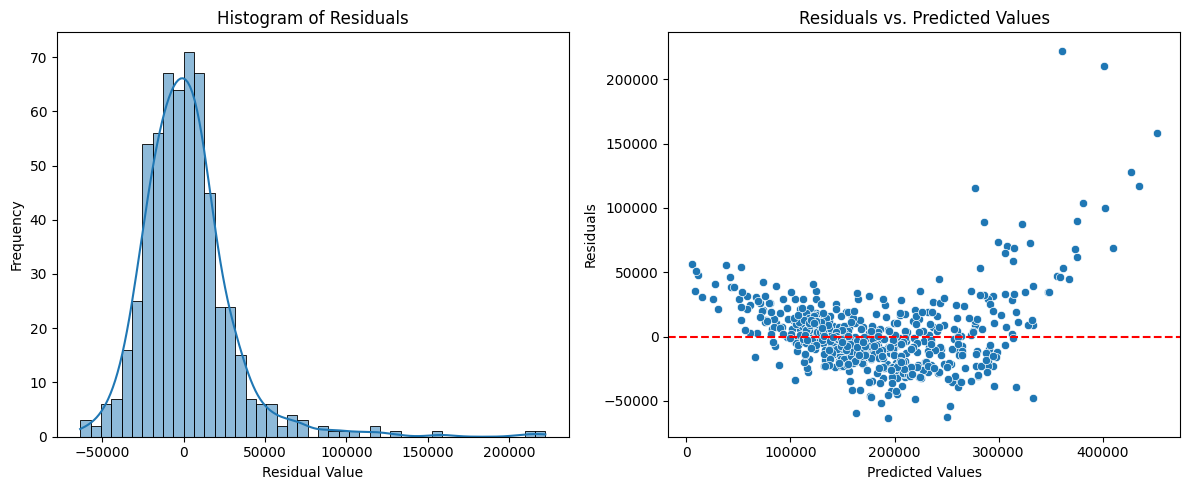

In [5]:
# define features and outcome
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

modeling_results = run_modeling_workflow(X, y, test_size=0.2, random_state=42)

### Backward Selection

Now let's run the same workflow with backward selection to see if it picks different features.

--- Running Cross-Validation on Training Data ---


Cross-validated R-squared (mean ± std): 0.8630 ± 0.0081
Cross-validated Mean Squared Error (mean ± std): 812955168.2469 ± 68940861.5338



Intercept: 179791.9282

Standardized Coefficients (Betas) from full data fit (using backward selection):
	Lot Frontage      :	 2087.96
	Lot Area          :	 4812.13
	Overall Qual      :	 23026.19
	Overall Cond      :	 6319.63
	Year Built        :	 13101.28
	Year Remod/Add    :	 2287.85
	Foundation        :	 4342.01
	BsmtFin SF 2      :	 -3298.79
	Bsmt Unf SF       :	 -10782.12
	Total Bsmt SF     :	 18980.36
	Gr Liv Area       :	 32583.39
	Bedroom AbvGr     :	 -7349.52
	Garage Area       :	 5710.22
	Wood Deck SF      :	 1689.75
	Yr Sold           :	 -2122.04
	garage_attached   :	 -4236.87
	Bldg Type_1Fam    :	 5532.71
	House Style_1Story:	 2464.34
	Roof Style_Gable  :	 -3317.46

--- Running Final Evaluation on Unseen Test Data ---
Final Test R-squared: 0.8838
Final Test MSE:       826017458.8885


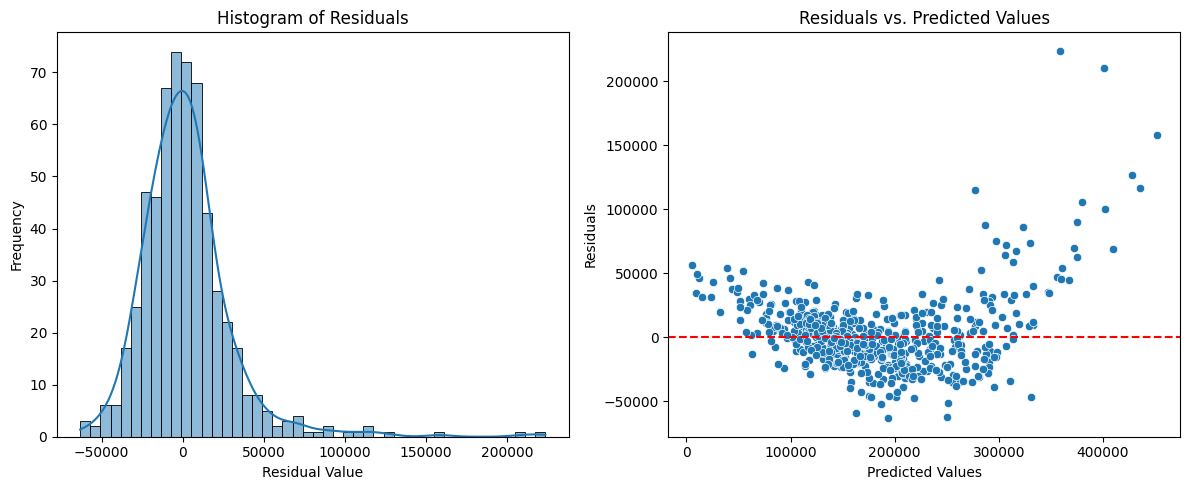

In [6]:
# Run backward selection
modeling_results_backward = run_modeling_workflow(
    X, y, test_size=0.2, random_state=42, selection_direction='backward'
)

## Interpreting Results

**Issue 1: Why is the coefficient for Bedroom AbvGr negative?**

One way to interpret the coefficients is that they reflect the effect of that single feature changing while all of the others are held constant.

Because `Gr Liv Area` is already in the model, the model is holding total square footage constant. If you have two 1,500 sq ft houses:
- House A has 3 bedrooms (500 sq ft each) — spacious rooms.
- House B has 5 bedrooms (300 sq ft each) — cramped rooms.

House B is worth *less* because the rooms are smaller. Adding a bedroom without adding square footage actually drops the price. The negative coefficient captures this real-world tradeoff.

**Issue 2: What are the residuals telling us?**

Look at the residuals vs. predicted plot. The errors form a **funnel shape** — small errors at low prices, massive errors at high prices. This pattern is called **heteroscedasticity**: the variance of the errors is not constant.

This is a problem because:
1.  The model treats a $10,000 error on a $100,000 house the same as a $10,000 error on a $500,000 house. But in percentage terms, those are very different (10% vs. 2%).
2.  Heteroscedasticity violates a key assumption of linear regression, meaning our confidence intervals and p-values are unreliable.

The root cause is the massive right skew of SalePrice — there are many modest homes and a few very expensive ones. The model struggles to predict the expensive ones because they dominate the error function.

**Issue 3: Multicollinearity**

Many of our features are highly correlated with each other (e.g., `Gr Liv Area` and `TotRms AbvGrd`). We'll assess this formally with VIF later in the notebook, but it's worth noting now: multicollinearity makes individual coefficients unstable and can confuse the feature selection process.

## Improving the Model: Log Transform

The residual funnel shape tells us the model cares about *absolute* dollar errors. But a $10,000 miss on a $100K house is a much bigger deal than a $10,000 miss on a $500K house. What we really want is for the model to care about *percentage* errors.

Taking the log of SalePrice does exactly this. It compresses the right tail of the distribution, making high-value homes less dominant in the error function. The result: the model pays equal attention to percentage errors across all price ranges.

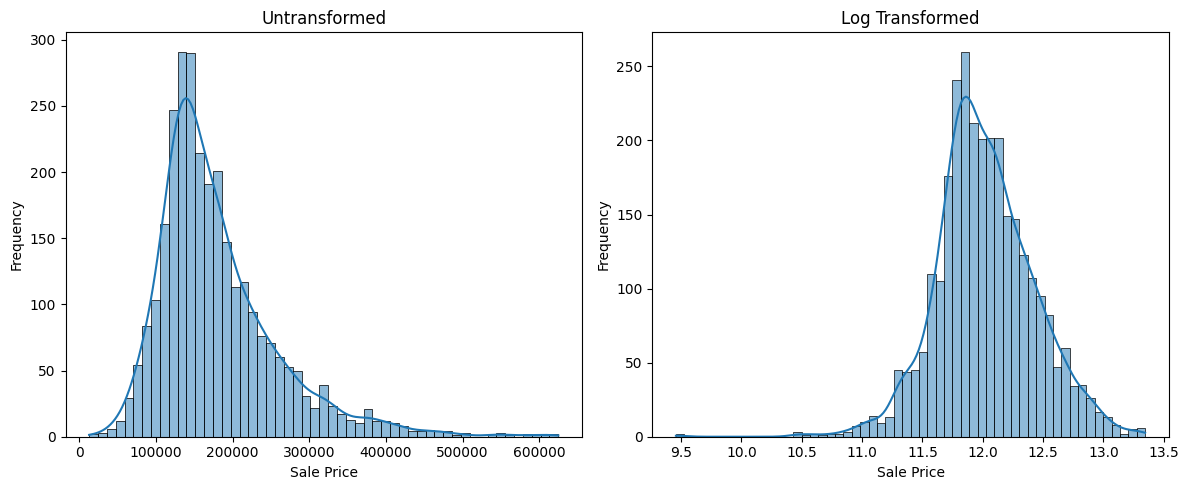

In [7]:
plt.figure(figsize=(12, 5))

# First histogram
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(x=df['SalePrice'], kde=True)
plt.title('Untransformed')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')

# Second histogram
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(x = df['SalePrice'].map(np.log), kde=True)
plt.title('Log Transformed')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')

plt.tight_layout() # Adjusts subplot params for a tight layout
plt.show()

--- Running Cross-Validation on Training Data ---


Cross-validated R-squared (mean ± std): 0.8871 ± 0.0001
Cross-validated Mean Squared Error (mean ± std): 0.0184 ± 0.0000



Intercept: 12.0180

Standardized Coefficients (Betas) from full data fit (using forward selection):
	Lot Area             :	    0.02
	Overall Qual         :	    0.12
	Overall Cond         :	    0.06
	Year Built           :	    0.09
	Year Remod/Add       :	    0.02
	Foundation           :	    0.02
	BsmtFin SF 1         :	    0.02
	Bsmt Unf SF          :	   -0.02
	Total Bsmt SF        :	    0.07
	Gr Liv Area          :	    0.14
	Bedroom AbvGr        :	   -0.01
	Fireplaces           :	    0.02
	Garage Cars          :	    0.03
	Enclosed Porch       :	    0.01
	Yr Sold              :	   -0.01
	MS Zoning_RL         :	    0.02
	Bldg Type_1Fam       :	    0.02
	Sale Condition_Normal:	    0.01

--- Running Final Evaluation on Unseen Test Data ---
Final Test R-squared: 0.9346
Final Test MSE:       0.0113


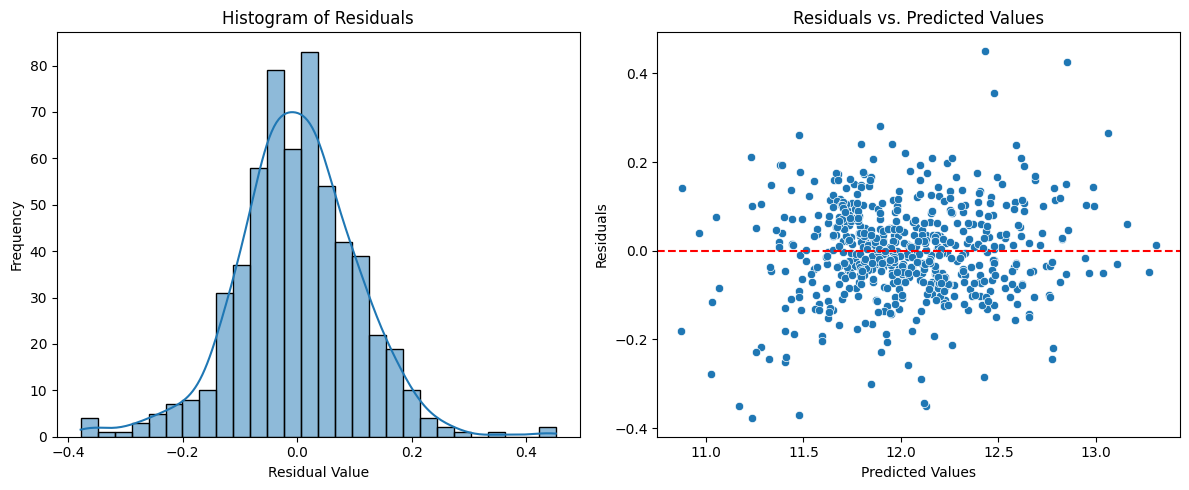

In [8]:
# define features and outcome
X = df.drop(columns=['SalePrice'])
ylog = df['SalePrice'].map(np.log)   # Note the log converison here

modeling_results = run_modeling_workflow(X, ylog, test_size=0.2, random_state=42)

### Did the Log Transform Help?

Compare the results:
- **Before log transform:** CV R² = 0.8623, Test R² = 0.8834
- **After log transform:** CV R² = 0.8871, Test R² = 0.9346

The CV R² improved modestly, but the test R² jumped by 5 points. Why the discrepancy? The log transform stabilized the variance across all price ranges, making the model more robust to the specific houses in the test set. The funnel-shaped residuals should now be much more evenly distributed.

Also notice the coefficients are now much smaller (0.02 to 0.14 range). This is because the target is now in log-units (~12.0) rather than dollars (~180,000). Each coefficient now represents the change in *log-price* per standard deviation change in the feature.

### Add Polynomials to Model Non-Linear Features

In standard linear regression, the model assumes a strict, straight-line relationship between your input features and your target variable. However, our data sometimes clearly follows a non-linear (curved in some way) pattern.

To capture curves, we can add squared features ($X^2$) that will allow the regression line to bend. Depending on the sign and weight of the coefficient, this curve can bend upwards (approximating accelerating/exponential growth or a U-shape) or downwards (capturing diminishing returns or an inverted U-shape).

By introducing these polynomial terms, we transform a simple model (straight lines only) into a much more flexible one (can account for curves in the data). Here is a brief approach on how and why to use them:

1. It is Still "Linear" Regression: Even though you are modeling a curve, the algorithm itself is still considered *Multiple Linear Regression*. This is because the model is linear in its **parameters** (the coefficients/weights). You are simply treating the squared term as a brand-new, independent feature.
Example Equation: $Y = \beta_0 + \beta_1(X) + \beta_2(X^2)$

2. Adding More Bends (Higher Degrees): While squared terms (degree 2) allow for exactly one bend (a parabola), you can add cubic terms ($X^3$, degree 3) to allow for two bends. This is particularly useful for modeling "S-curves," where growth starts slow, accelerates, and then levels off.

3. Some cautions to keep in mind:
* If you include a squared term ($X^2$) in your model, you should almost always include the base linear term ($X$) as well, even if its individual p-value doesn't seem significant. This anchors the curve correctly. We get to see if the curve is significant while controlling for the straight line version of the feature.
* Beware of Overfitting: It is tempting to add $X^3$, $X^4$, or $X^5$ to make the line fit your training data perfectly. However, higher-degree polynomials cause the regression line to become wildly "wiggly," leading to terrible predictions on unseen data. Rarely go above a degree of 2 or 3.
* Watch out for Multicollinearity: A base feature ($X$) and its square ($X^2$) are often highly correlated, which can confuse the model's coefficients. You can fix this by *centering* or *standardizing* your data (subtracting the mean and dividing by the standard deviation) before squaring it. This type of multicolinearity is sometimes called structural multicollinearity and it is NOT fixed by using the standard scaler in the pipeline. You must standardize when creating the polynomial. If you do not do this, your R2 and mse will be fine when running OLS, but your p-values will not. So you won't be able to tell if your polynomials are significantly adding to the model.

### Some Examples of Potential Polynomials for Ames

#### 1. `Overall Qual`
* **The Logic:** In a standard linear model, the jump from a Quality 4 to 5 adds the exact same dollar amount as the jump from Quality 9 to 10. But in real estate, ultra-luxury finishes command an exponential premium.
* **The Polynomial:** Adding `Overall Qual ** 2`.
* **What We Might See:** Both the linear and squared terms will likely be positive. The model will draw an upward-curving "hockey stick" line, proving that a 1-point increase at the high end of the scale is worth tens of thousands of dollars more than a 1-point increase at the low end.

### 2. `Bedroom AbvGr`
* **The Logic:** As we discussed with the negative coefficient, adding bedrooms while holding square footage constant means smaller rooms. But is the penalty linear? Going from 2 to 3 bedrooms in a 1,500 sq ft house is normal. Going from 5 to 6 bedrooms in that same house means you are living in a bizarre labyrinth of closets.
* **The Polynomial:** Adding `Bedroom AbvGr ** 2`.
* **What We Might See:** An inverted U-shape or a sharply steepening downward curve. The penalty for cramming one extra bedroom into a house gets exponentially worse the more bedrooms you add.

### 3. `Garage Area` Diminishing Returns
* **The Logic:** Going from a 0-car garage to a 2-car garage adds immense value to a home. Going from a 2-car to a 3-car garage is a nice luxury. But going from a 4-car to a 6-car garage adds very little extra value because almost no normal homebuyer needs that much space—unless they are a massive car collector.
* **The Polynomial:** Adding `Garage Area ** 2`.
* **What We Might See:** The linear term (`Garage Area`) will be positive, but the squared term (`Garage Area ** 2`) will be **negative**. This is the classic mathematical signature of "diminishing returns." The curve goes up, but it flattens out as the garage gets massive.



--- Running Cross-Validation on Training Data ---


Cross-validated R-squared (mean ± std): 0.8808 ± 0.0005
Cross-validated Mean Squared Error (mean ± std): 0.0194 ± 0.0000



Intercept: 12.0180

Standardized Coefficients (Betas) from full data fit (using forward selection):
	Lot Area      :	    0.02
	Overall Qual  :	    0.13
	Overall Cond  :	    0.07
	Year Built    :	    0.11
	BsmtFin SF 1  :	    0.04
	Total Bsmt SF :	    0.05
	Gr Liv Area   :	    0.14
	Garage Area   :	    0.03
	Bldg Type_1Fam:	    0.02

--- Running Final Evaluation on Unseen Test Data ---
Final Test R-squared: 0.9276
Final Test MSE:       0.0125


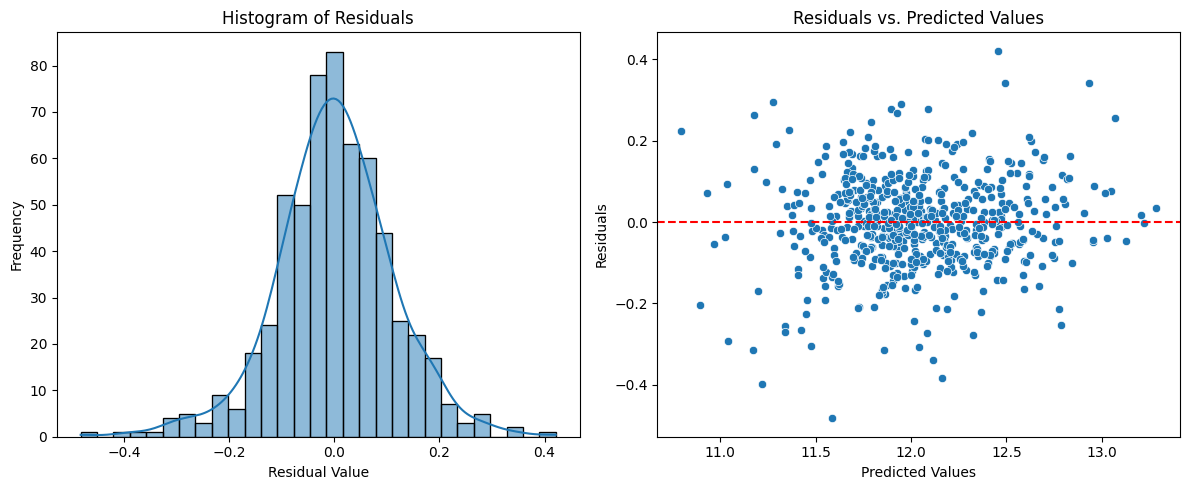

In [9]:
# Let's test whether polynomial features add value.
# We'll standardize first (to avoid structural multicollinearity),
# then create squared terms, and run them through our workflow.

from sklearn.preprocessing import StandardScaler

# Standardize the base features before squaring
linear_features = ['Overall Qual', 'Bedroom AbvGr', 'Garage Area']
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[linear_features])
temp_df = pd.DataFrame(df_scaled, columns=linear_features, index=df.index)

# Create squared terms from the standardized values
for col in linear_features:
    df[f'{col}_Sqr'] = temp_df[col] ** 2

# Build the feature set: original features + polynomials
poly_features = [
    'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built',
    'Year Remod/Add', 'BsmtFin SF 1', 'Total Bsmt SF',
    'Gr Liv Area', 'Bedroom AbvGr', 'Garage Area',
    'Wood Deck SF', 'Yr Sold', 'garage_attached',
    'Bldg Type_1Fam', 'Roof Style_Gable',
    'Overall Qual_Sqr', 'Bedroom AbvGr_Sqr', 'Garage Area_Sqr'
]

X_poly = df[poly_features]
y_poly = df['SalePrice'].map(np.log)

# Run through the same workflow (forward selection)
modeling_results_poly = run_modeling_workflow(
    X_poly, y_poly, test_size=0.2, random_state=42
)

### Did the Polynomials Help?

Forward selection did not choose any of the polynomial features. The model achieved strong accuracy (R² ≈ 0.90) without them.

This doesn't mean non-linear relationships don't exist in the data. It means that, given the features already selected, the polynomial terms didn't add enough *additional* explanatory power to justify their inclusion. Forward selection is conservative — it only adds features that clearly improve the cross-validation score.

In Part 3, we'll see that regularization (Ridge, Lasso) handles this situation more gracefully. Instead of an all-or-nothing decision about whether to include a polynomial, regularization can shrink its coefficient toward zero while still allowing it to contribute if it helps.

---

### Assessing Multi-Colinearity with VIF

In regression analysis, your input features should ideally be strongly correlated with your target variable, but not with each other. When independent variables overlap too much, a problem known as multicollinearity, it confuses the model, making it nearly impossible to figure out the individual impact of each feature and causing the coefficient weights to become highly unstable. The Variance Inflation Factor (VIF) is a diagnostic metric used to measure and expose this exact problem. It calculates exactly how much the variance (or uncertainty) of a specific feature's weight is "inflated" due to its correlation with the other predictors. In simple terms, VIF gives each of your features a score: a score of 1 means the feature is completely independent, while higher scores (typically above 5 or 10) act as a mathematical red flag that a feature is redundant and muddying your model.

VIF Interpretation:
- VIF = 1: No correlation with other features
- VIF 1-5: Moderate correlation (usually acceptable)
- VIF > 5: High correlation - consider removing or combining features
- VIF > 10: Very high correlation - likely problematic


In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X: pd.DataFrame, threshold: float = 5.0) -> pd.DataFrame:
    """
    Calculate Variance Inflation Factor (VIF) for each feature.

    Args:
        X: DataFrame with features (must be numeric, no NaN)
        threshold: VIF value above which features are flagged (default: 5.0)

    Returns:
        DataFrame with features and their VIF values
    """
    # Add constant for VIF calculation
    X_with_const = X.assign(const=1)

    vif_data = []
    for i, col in enumerate(X.columns):
        vif_value = variance_inflation_factor(X_with_const.values, i)
        vif_data.append({'Feature': col, 'VIF': vif_value})

    vif_df = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

    # Flag high VIF features
    high_vif = vif_df[vif_df['VIF'] > threshold]
    print(f"Features with VIF > {threshold} (potential multicollinearity issues):")
    if len(high_vif) > 0:
        print(high_vif.to_string(index=False))
    else:
        print("  None - all features below threshold")

    return vif_df

# Example usage with selected features
X = df.select_dtypes(include=np.number).drop(columns=['SalePrice'])
vif_results = calculate_vif(X, threshold=5.0)
print("\nAll VIF values:")
print(vif_results.to_string(index=False))

Features with VIF > 5.0 (potential multicollinearity issues):
      Feature        VIF
  Gr Liv Area 118.112908
   2nd Flr SF  91.458154
   1st Flr SF  72.771743
Total Bsmt SF   9.668766
  Bsmt Unf SF   8.037787
 BsmtFin SF 1   7.773060
  Garage Cars   6.772699
  Garage Area   6.334244

All VIF values:
          Feature        VIF
      Gr Liv Area 118.112908
       2nd Flr SF  91.458154
       1st Flr SF  72.771743
    Total Bsmt SF   9.668766
      Bsmt Unf SF   8.037787
     BsmtFin SF 1   7.773060
      Garage Cars   6.772699
      Garage Area   6.334244
       Year Built   4.712881
    TotRms AbvGrd   4.035941
    Garage Yr Blt   3.556798
     Overall Qual   3.110283
        Full Bath   2.759582
   Year Remod/Add   2.555017
    Bedroom AbvGr   2.521090
        Half Bath   2.142085
   Bsmt Full Bath   1.984705
       Foundation   1.984248
     Overall Cond   1.666937
     Lot Frontage   1.563489
      MS SubClass   1.557260
       Fireplaces   1.537436
  Garage Area_Sqr   1.392356


First, let's check VIF across all numeric features:

First, let's check VIF across all numeric features:

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X: pd.DataFrame, threshold: float = 5.0) -> pd.DataFrame:
    """
    Calculate Variance Inflation Factor (VIF) for each feature.

    Args:
        X: DataFrame with features (must be numeric, no NaN)
        threshold: VIF value above which features are flagged (default: 5.0)

    Returns:
        DataFrame with features and their VIF values
    """
    # Add constant for VIF calculation
    X_with_const = X.assign(const=1)

    vif_data = []
    for i, col in enumerate(X.columns):
        vif_value = variance_inflation_factor(X_with_const.values, i)
        vif_data.append({'Feature': col, 'VIF': vif_value})

    vif_df = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

    # Flag high VIF features
    high_vif = vif_df[vif_df['VIF'] > threshold]
    print(f"Features with VIF > {threshold} (potential multicollinearity issues):")
    if len(high_vif) > 0:
        print(high_vif.to_string(index=False))
    else:
        print("  None - all features below threshold")

    return vif_df

# Example usage with selected features
X = df.select_dtypes(include=np.number).drop(columns=['SalePrice'])
vif_results = calculate_vif(X, threshold=5.0)
print("\nAll VIF values:")
print(vif_results.to_string(index=False))

Features with VIF > 5.0 (potential multicollinearity issues):
      Feature        VIF
  Gr Liv Area 118.112908
   2nd Flr SF  91.458154
   1st Flr SF  72.771743
Total Bsmt SF   9.668766
  Bsmt Unf SF   8.037787
 BsmtFin SF 1   7.773060
  Garage Cars   6.772699
  Garage Area   6.334244

All VIF values:
          Feature        VIF
      Gr Liv Area 118.112908
       2nd Flr SF  91.458154
       1st Flr SF  72.771743
    Total Bsmt SF   9.668766
      Bsmt Unf SF   8.037787
     BsmtFin SF 1   7.773060
      Garage Cars   6.772699
      Garage Area   6.334244
       Year Built   4.712881
    TotRms AbvGrd   4.035941
    Garage Yr Blt   3.556798
     Overall Qual   3.110283
        Full Bath   2.759582
   Year Remod/Add   2.555017
    Bedroom AbvGr   2.521090
        Half Bath   2.142085
   Bsmt Full Bath   1.984705
       Foundation   1.984248
     Overall Cond   1.666937
     Lot Frontage   1.563489
      MS SubClass   1.557260
       Fireplaces   1.537436
  Garage Area_Sqr   1.392356


Many of our most important features are highly correlated. `Gr Liv Area` has a VIF of 118 — extreme multicollinearity. This suggests multicollinearity is a significant issue with the full feature set.

But forward selection picked a reduced set of features. Let's check whether *those* features are still multicollinear.

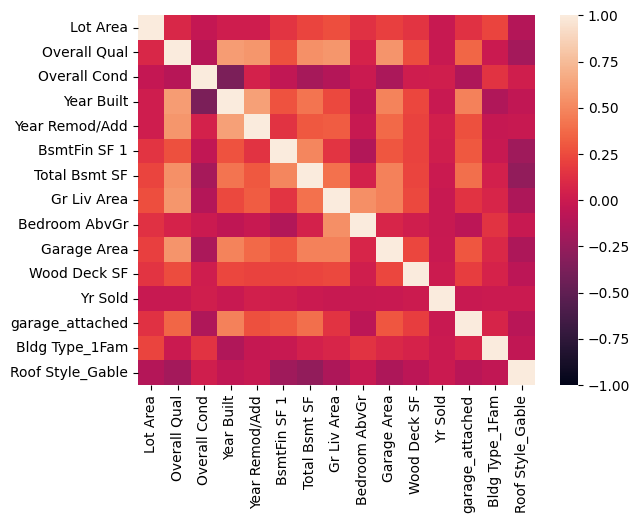

In [12]:
reduced_features = [
    'Lot Area',
    'Overall Qual',
    'Overall Cond',
    'Year Built',
    'Year Remod/Add',
    'BsmtFin SF 1',
    'Total Bsmt SF',
    'Gr Liv Area',
    'Bedroom AbvGr',
    'Garage Area',
    'Wood Deck SF',
    'Yr Sold',
    'garage_attached',
    'Bldg Type_1Fam',
    'Roof Style_Gable']

sns.heatmap(df[reduced_features].corr(), vmin=-1, vmax=1)
plt.show()

In [13]:
# Calculate the correlation matrix
corr_matrix = df[reduced_features].corr()

# Unstack the correlation matrix to easily filter
stacked_corr = corr_matrix.stack()

# Filter for correlations above .7 in absolute value and exclude self-correlations
high_corr = stacked_corr[(abs(stacked_corr) > 0.7) & (stacked_corr != 1)]

# Sort for better readability
high_corr = high_corr.sort_values(ascending=False)

print("Features with absolute correlation > 0.7:")
if not high_corr.empty:
  # Print each pair, avoiding duplicates (e.g., A-B and B-A)
  printed_pairs = set()
  for (feature1, feature2), correlation in high_corr.items():
    # Ensure consistent order for pairs to avoid printing (A,B) and then (B,A)
    if (feature2, feature1) not in printed_pairs:
      print(f"  {feature1} - {feature2}: {correlation:.4f}")
      printed_pairs.add((feature1, feature2))
else:
  print("  No correlations above 0.7 found (excluding self-correlation).")

Features with absolute correlation > 0.7:
  No correlations above 0.7 found (excluding self-correlation).


Now let's check VIF on just the features selected by forward selection:

In [14]:
reduced_features = [
    'Lot Area',
    'Overall Qual',
    'Overall Cond',
    'Year Built',
    'Year Remod/Add',
    'BsmtFin SF 1',
    'Total Bsmt SF',
    'Gr Liv Area',
    'Bedroom AbvGr',
    'Garage Area',
    'Wood Deck SF',
    'Yr Sold',
    'garage_attached',
    'Bldg Type_1Fam',
    'Roof Style_Gable']

X_reduced = df[reduced_features].select_dtypes(include=np.number)
vif_results = calculate_vif(X_reduced, threshold=5.0)
print("\nAll VIF values:")
print(vif_results.to_string(index=False))

Features with VIF > 5.0 (potential multicollinearity issues):
  None - all features below threshold

All VIF values:
       Feature      VIF
    Year Built 2.857857
  Overall Qual 2.851837
   Gr Liv Area 2.841694
Year Remod/Add 2.109863
 Total Bsmt SF 1.900664
   Garage Area 1.761964
 Bedroom AbvGr 1.694568
  Overall Cond 1.445705
  BsmtFin SF 1 1.439246
  Wood Deck SF 1.152086
      Lot Area 1.143946
       Yr Sold 1.006236


The reduced feature set has no VIF values above 5. Forward selection effectively filtered out the most redundant features.

But there's a catch: **multicollinearity may have affected the selection process itself.** When two features are highly correlated (like `Gr Liv Area` and `TotRms AbvGrd` at r=0.81), forward selection picks one and ignores the other — not because the ignored feature is unimportant, but because its information is redundant with the one already selected. The algorithm can't tell which one is "truly" important.

This means our model's **predictions** may still be good, but the **coefficients are not stable**. If we collected a slightly different sample of houses, the selected features and their coefficients might change dramatically.

Let's confirm the correlations across all features:

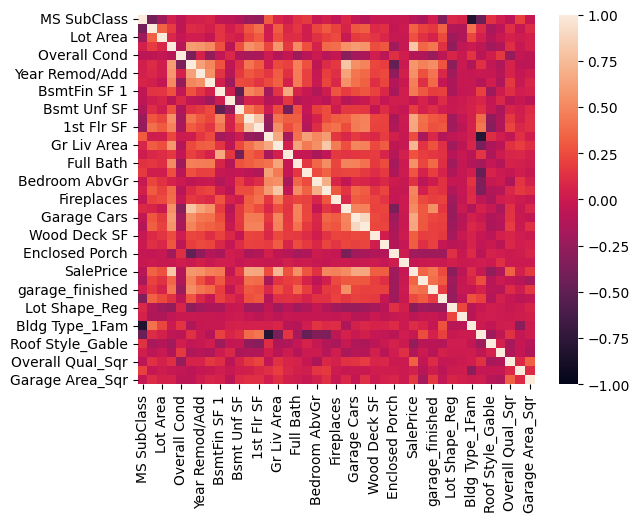

In [15]:
sns.heatmap(df.corr(), vmin=-1, vmax=1)
plt.show()

In [16]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Unstack the correlation matrix to easily filter
stacked_corr = corr_matrix.stack()

# Filter for correlations above .7 in absolute value and exclude self-correlations
high_corr = stacked_corr[(abs(stacked_corr) > 0.7) & (stacked_corr != 1)]

# Sort for better readability
high_corr = high_corr.sort_values(ascending=False)

print("Features with absolute correlation > 0.7:")
if not high_corr.empty:
  # Print each pair, avoiding duplicates (e.g., A-B and B-A)
  printed_pairs = set()
  for (feature1, feature2), correlation in high_corr.items():
    # Ensure consistent order for pairs to avoid printing (A,B) and then (B,A)
    if (feature2, feature1) not in printed_pairs:
      print(f"  {feature1} - {feature2}: {correlation:.4f}")
      printed_pairs.add((feature1, feature2))
else:
  print("No correlations above 0.7 found (excluding self-correlation).")

Features with absolute correlation > 0.7:
  Garage Cars - Garage Area: 0.8921
  Gr Liv Area - TotRms AbvGrd: 0.8091
  SalePrice - Overall Qual: 0.8052
  Year Built - Garage Yr Blt: 0.7962
  Total Bsmt SF - 1st Flr SF: 0.7839
  Gr Liv Area - SalePrice: 0.7195
  House Style_1Story - 2nd Flr SF: -0.7922
  MS SubClass - Bldg Type_1Fam: -0.8154


## Summary

We've built a model that achieves R² ≈ 0.93 on the test set using forward selection and a log-transformed target. But we've also identified several issues:

1.  **Multicollinearity is pervasive.** While forward selection reduced the most extreme cases, the underlying correlations between features mean our coefficients are not stable or individually interpretable.
2.  **Forward selection may have missed important features.** When features are correlated, the algorithm picks one and ignores the others. A different random split might have picked different features.
3.  **Polynomial features were not selected**, but this doesn't mean non-linearity doesn't exist — it means forward selection's all-or-nothing approach couldn't justify their inclusion.

**In Part 3, we'll address all three issues with regularization.** Ridge, Lasso, and ElasticNet penalize large coefficients, making the model less sensitive to which correlated features are included. They also handle polynomial features more gracefully by shrinking their coefficients rather than dropping them entirely.